In [1]:
import pandas as pd

# 1. Cargar los 4 archivos CSV
# Asegúrate de que estén en la misma carpeta que este script
movies = pd.read_csv('movies.csv')
links = pd.read_csv('links.csv')
ratings = pd.read_csv('ratings.csv')
tags = pd.read_csv('tags.csv')

print("Archivos cargados correctamente.")

# 2. Vincular películas con sus links (IDs de IMDb y TMDb)
# Usamos 'movieId' como clave principal. 
# Esto añade las columnas imdbId y tmdbId a la información de la película.
df_movies_info = pd.merge(movies, links, on='movieId', how='left')

# 3. Vincular con los ratings (calificaciones de usuarios)
# Esto creará una fila por cada calificación que haya recibido una película.
df_final = pd.merge(df_movies_info, ratings, on='movieId', how='left')



# 5. Ver el resultado final
print("\nColumnas del DataFrame final:")
print(df_final.columns.tolist())

print(f"\nTotal de filas generadas: {len(df_final)}")
print("\nPrimeras 5 filas:")
print(df_final.head())



Archivos cargados correctamente.

Columnas del DataFrame final:
['movieId', 'title', 'genres', 'imdbId', 'tmdbId', 'userId', 'rating', 'timestamp']

Total de filas generadas: 100854

Primeras 5 filas:
   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   imdbId  tmdbId  userId  rating     timestamp  
0  114709   862.0     1.0     4.0  9.649827e+08  
1  114709   862.0     5.0     4.0  8.474350e+08  
2  114709   862.0     7.0     4.5  1.106636e+09  
3  114709   862.0    15.0     2.5  1.510578e+09  
4  114709   862.0    17.0     4.5  1.305696e+09  


In [5]:
## Aquí vamos a crear dos nuevas columnas: 'year' y 'title_clean', con el fin de separar el año 
## del título de la película y limpiar el título para que no tenga el año incluido


# Extraer año desde el título, eliminar paréntesis y convertir a Integer
df_final['year'] = df_final['title'].str.extract(r'\((\d{4})\)').astype('Int64')

# Extraer solo el título sin el año (elimina el patrón "(YYYY)" y espacios sobrantes)
df_final['title_clean'] = df_final['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()

df_final.to_csv('peliculas_completo_year.csv', index=False)

Dashboard generado correctamente.


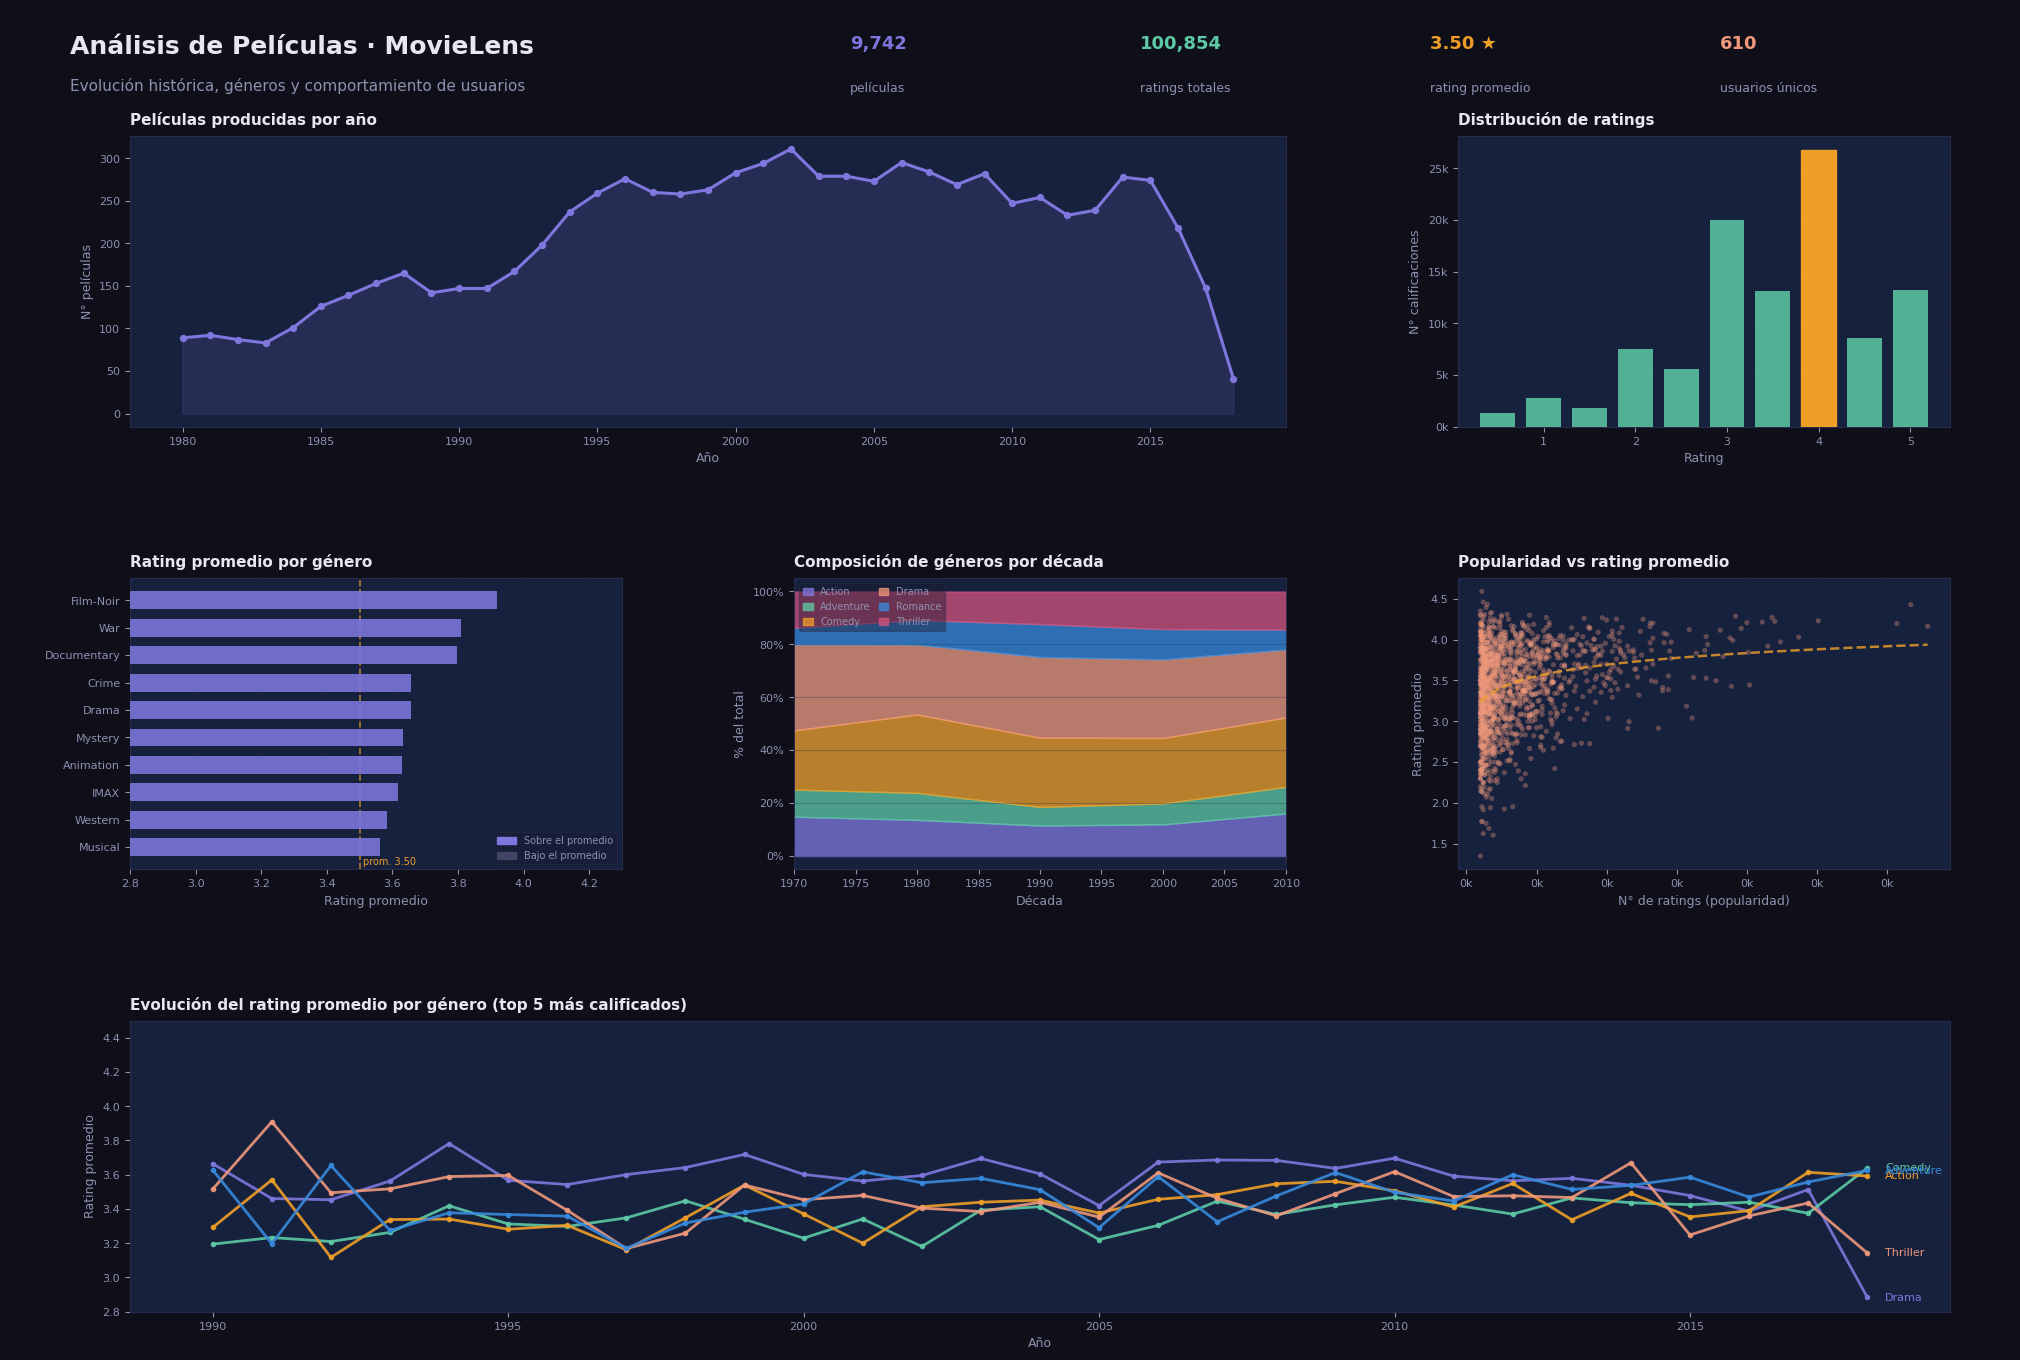

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import FuncFormatter

# ─────────────────────────────────────────
# CARGA Y PREPARACIÓN DE DATOS
# ─────────────────────────────────────────

# ── Gráfico 1: Películas por año (serie de tiempo) ──
peliculas_unicas = df_final.drop_duplicates(subset='movieId')
peliculas_por_año = (
    peliculas_unicas
    .dropna(subset=['year'])
    .query("year >= 1980")
    .groupby('year')['movieId']
    .nunique()
    .reset_index()
    .rename(columns={'movieId': 'count'})
)
peliculas_por_año['year'] = peliculas_por_año['year'].astype(int)

# ── Gráfico 2: Distribución de ratings ──
rating_dist = df_final['rating'].value_counts().sort_index()

# ── Gráfico 3: Rating promedio por género ──
generos_exp = df_final.assign(genero=df_final['genres'].str.split('|')).explode('genero')
generos_exp = generos_exp[generos_exp['genero'] != '(no genres listed)']
rating_genero = (
    generos_exp
    .groupby('genero')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .query("count >= 200")
    .sort_values('mean', ascending=True)
    .tail(10)
)

# ── Gráfico 4: Composición de géneros por década ──
peliculas_unicas2 = df_final.drop_duplicates(subset='movieId').copy()
peliculas_unicas2 = peliculas_unicas2.dropna(subset=['year']).copy()
peliculas_unicas2['decada'] = (peliculas_unicas2['year'] // 10 * 10).astype(int)
peliculas_unicas2 = peliculas_unicas2[peliculas_unicas2['decada'] >= 1970]
generos_dec = peliculas_unicas2.assign(genero=peliculas_unicas2['genres'].str.split('|')).explode('genero')
generos_dec = generos_dec[generos_dec['genero'] != '(no genres listed)']
top_generos = (
    generos_dec.groupby('genero')['movieId']
    .nunique()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)
comp_decada = (
    generos_dec[generos_dec['genero'].isin(top_generos)]
    .groupby(['decada', 'genero'])['movieId']
    .nunique()
    .unstack(fill_value=0)
)
comp_decada_pct = comp_decada.div(comp_decada.sum(axis=1), axis=0) * 100

# ── Gráfico 5: Scatter popularidad vs rating ──
scatter_data = (
    df_final.groupby('movieId')
    .agg(n_ratings=('rating', 'count'), avg_rating=('rating', 'mean'))
    .reset_index()
    .query("n_ratings >= 10")
)
# Muestra para no saturar el scatter
scatter_sample = scatter_data.sample(min(1500, len(scatter_data)), random_state=42)

# ── Gráfico 6: Evolución rating por género (top 5) ──
top5_generos = (
    generos_exp.groupby('genero')['rating']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
evol = (
    generos_exp[generos_exp['genero'].isin(top5_generos)]
    .dropna(subset=['year'])
    .query("year >= 1990")
    .groupby(['year', 'genero'])['rating']
    .mean()
    .reset_index()
)
evol['year'] = evol['year'].astype(int)

# ─────────────────────────────────────────
# PALETA Y ESTILOS DARK MODE
# ─────────────────────────────────────────

BG_MAIN   = '#0f0f1a'
BG_PANEL  = '#1a1a2e'
BG_CARD   = '#16213e'
BORDER    = '#2a2a4a'
TEXT_PRI  = '#e8e6f0'
TEXT_SEC  = '#9090b0'
PURPLE    = '#7F77DD'
TEAL      = '#5DCAA5'
AMBER     = '#EF9F27'
CORAL     = '#F0997B'
BLUE      = '#378ADD'
PINK      = '#D4537E'

PALETTE_GENEROS = [PURPLE, TEAL, AMBER, CORAL, BLUE, PINK]

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'text.color': TEXT_PRI,
    'axes.facecolor': BG_CARD,
    'axes.edgecolor': BORDER,
    'axes.labelcolor': TEXT_SEC,
    'axes.titlecolor': TEXT_PRI,
    'xtick.color': TEXT_SEC,
    'ytick.color': TEXT_SEC,
    'grid.color': BORDER,
    'grid.alpha': 0.5,
    'figure.facecolor': BG_MAIN,
    'legend.facecolor': BG_PANEL,
    'legend.edgecolor': BORDER,
    'legend.labelcolor': TEXT_SEC,
})

# ─────────────────────────────────────────
# FIGURA Y LAYOUT
# ─────────────────────────────────────────

fig = plt.figure(figsize=(20, 14), facecolor=BG_MAIN)
fig.patch.set_facecolor(BG_MAIN)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    left=0.06, right=0.97,
    top=0.91, bottom=0.07,
    hspace=0.52, wspace=0.35
)

# ─── HEADER ───────────────────────────────────
ax_title = fig.add_axes([0, 0.93, 1, 0.07])
ax_title.set_facecolor(BG_PANEL)
ax_title.set_xlim(0, 1)
ax_title.set_ylim(0, 1)
ax_title.axis('off')

ax_title.text(0.03, 0.62, 'Análisis de Películas · MovieLens',
              fontsize=18, fontweight='bold', color=TEXT_PRI, va='center')
ax_title.text(0.03, 0.22, 'Evolución histórica, géneros y comportamiento de usuarios',
              fontsize=11, color=TEXT_SEC, va='center')

# KPIs en header
kpis = [
    (f"{peliculas_unicas['movieId'].nunique():,}", 'películas', PURPLE),
    (f"{len(df_final):,}", 'ratings totales', TEAL),
    (f"{df_final['rating'].mean():.2f} ★", 'rating promedio', AMBER),
    (f"{df_final['userId'].nunique():,}", 'usuarios únicos', CORAL),
]
for i, (val, label, color) in enumerate(kpis):
    x = 0.42 + i * 0.145
    ax_title.text(x, 0.65, val, fontsize=13, fontweight='bold',
                  color=color, va='center', ha='left')
    ax_title.text(x, 0.2, label, fontsize=9, color=TEXT_SEC, va='center', ha='left')

# ─────────────────────────────────────────
# GRÁFICO 1: Serie de tiempo (fila 0, cols 0-1)
# ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.set_facecolor(BG_CARD)

ax1.fill_between(peliculas_por_año['year'], peliculas_por_año['count'],
                 alpha=0.15, color=PURPLE)
ax1.plot(peliculas_por_año['year'], peliculas_por_año['count'],
         color=PURPLE, linewidth=2.2, zorder=3)
ax1.scatter(peliculas_por_año['year'], peliculas_por_año['count'],
            color=PURPLE, s=18, zorder=4)

ax1.set_title('Películas producidas por año', fontsize=11, fontweight='bold',
              color=TEXT_PRI, pad=8, loc='left')
ax1.set_xlabel('Año', fontsize=9)
ax1.set_ylabel('N° películas', fontsize=9)
ax1.tick_params(labelsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[:].set_edgecolor(BORDER)

# ─────────────────────────────────────────
# GRÁFICO 2: Distribución de ratings (fila 0, col 2)
# ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(BG_CARD)

bars = ax2.bar(rating_dist.index, rating_dist.values,
               color=TEAL, alpha=0.85, width=0.38, zorder=3)
# Resaltar la barra más alta
max_idx = rating_dist.values.argmax()
bars[max_idx].set_color(AMBER)
bars[max_idx].set_alpha(1.0)

ax2.set_title('Distribución de ratings', fontsize=11, fontweight='bold',
              color=TEXT_PRI, pad=8, loc='left')
ax2.set_xlabel('Rating', fontsize=9)
ax2.set_ylabel('N° calificaciones', fontsize=9)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.tick_params(labelsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[:].set_edgecolor(BORDER)

# ─────────────────────────────────────────
# GRÁFICO 3: Rating por género (fila 1, col 0)
# ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(BG_CARD)

promedio_global = df_final['rating'].mean()
colores_barras = [PURPLE if v >= promedio_global else '#444466'
                  for v in rating_genero['mean']]

ax3.barh(rating_genero['genero'], rating_genero['mean'],
         color=colores_barras, alpha=0.88, height=0.65, zorder=3)
ax3.axvline(promedio_global, color=AMBER, linewidth=1.2,
            linestyle='--', alpha=0.7, zorder=2)
ax3.text(promedio_global + 0.01, -0.7, f'prom. {promedio_global:.2f}',
         fontsize=7, color=AMBER, va='bottom')

ax3.set_title('Rating promedio por género', fontsize=11, fontweight='bold',
              color=TEXT_PRI, pad=8, loc='left')
ax3.set_xlabel('Rating promedio', fontsize=9)
ax3.tick_params(labelsize=8)
ax3.set_xlim(2.8, 4.3)
ax3.grid(axis='x', alpha=0.3)
ax3.spines[:].set_edgecolor(BORDER)

legend_patches = [
    mpatches.Patch(color=PURPLE, label='Sobre el promedio'),
    mpatches.Patch(color='#444466', label='Bajo el promedio'),
]
ax3.legend(handles=legend_patches, fontsize=7, loc='lower right',
           framealpha=0.4)

# ─────────────────────────────────────────
# GRÁFICO 4: Composición por década (fila 1, col 1)
# ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(BG_CARD)

decadas = comp_decada_pct.index.tolist()
base = np.zeros(len(decadas))
for i, genero in enumerate(comp_decada_pct.columns):
    vals = comp_decada_pct[genero].values
    ax4.fill_between(decadas, base, base + vals,
                     alpha=0.75, color=PALETTE_GENEROS[i % len(PALETTE_GENEROS)],
                     label=genero)
    base += vals

ax4.set_title('Composición de géneros por década', fontsize=11, fontweight='bold',
              color=TEXT_PRI, pad=8, loc='left')
ax4.set_xlabel('Década', fontsize=9)
ax4.set_ylabel('% del total', fontsize=9)
ax4.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax4.tick_params(labelsize=8)
ax4.set_xlim(decadas[0], decadas[-1])
ax4.grid(axis='y', alpha=0.3)
ax4.spines[:].set_edgecolor(BORDER)
ax4.legend(fontsize=7, loc='upper left', framealpha=0.4,
           ncol=2, columnspacing=0.8, handlelength=1)

# ─────────────────────────────────────────
# GRÁFICO 5: Scatter popularidad vs rating (fila 1, col 2)
# ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(BG_CARD)

ax5.scatter(scatter_sample['n_ratings'], scatter_sample['avg_rating'],
            color=CORAL, alpha=0.35, s=14, zorder=3, edgecolors='none')

# Línea de tendencia
z = np.polyfit(np.log1p(scatter_sample['n_ratings']),
               scatter_sample['avg_rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_sample['n_ratings'].min(),
                     scatter_sample['n_ratings'].max(), 200)
ax5.plot(x_line, p(np.log1p(x_line)), color=AMBER,
         linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)

ax5.set_title('Popularidad vs rating promedio', fontsize=11, fontweight='bold',
              color=TEXT_PRI, pad=8, loc='left')
ax5.set_xlabel('N° de ratings (popularidad)', fontsize=9)
ax5.set_ylabel('Rating promedio', fontsize=9)
ax5.tick_params(labelsize=8)
ax5.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax5.grid(alpha=0.3)
ax5.spines[:].set_edgecolor(BORDER)

# ─────────────────────────────────────────
# GRÁFICO 6: Evolución rating por género (fila 2, cols 0-2)
# ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.set_facecolor(BG_CARD)

for i, genero in enumerate(top5_generos):
    data_g = evol[evol['genero'] == genero].sort_values('year')
    color = PALETTE_GENEROS[i % len(PALETTE_GENEROS)]
    ax6.plot(data_g['year'], data_g['rating'],
             color=color, linewidth=2, alpha=0.9,
             marker='o', markersize=3, label=genero)
    # Etiqueta al final de cada línea
    if not data_g.empty:
        last = data_g.iloc[-1]
        ax6.text(last['year'] + 0.3, last['rating'], genero,
                 fontsize=8, color=color, va='center')

ax6.set_title('Evolución del rating promedio por género (top 5 más calificados)',
              fontsize=11, fontweight='bold', color=TEXT_PRI, pad=8, loc='left')
ax6.set_xlabel('Año', fontsize=9)
ax6.set_ylabel('Rating promedio', fontsize=9)
ax6.tick_params(labelsize=8)
ax6.set_ylim(2.8, 4.5)
ax6.grid(axis='y', alpha=0.3)
ax6.spines[:].set_edgecolor(BORDER)

# ─────────────────────────────────────────
# GUARDAR
# ─────────────────────────────────────────


print("Dashboard generado correctamente.")


In [19]:
"""
Dashboard interactivo de películas · MovieLens
Requiere: pip install plotly pandas
Ejecutar:  python3 dashboard_peliculas_plotly.py
Genera:    dashboard_peliculas.html  (se abre en el navegador)
"""

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─────────────────────────────────────────────────────────
# PALETA DARK MODE
# ─────────────────────────────────────────────────────────

BG_MAIN  = '#0f0f1a'
BG_CARD  = '#16213e'
BG_PANEL = '#1a1a2e'
BORDER   = '#2a2a4a'
TEXT_PRI = '#e8e6f0'
TEXT_SEC = '#9090b0'

PURPLE = '#7F77DD'
TEAL   = '#5DCAA5'
AMBER  = '#EF9F27'
CORAL  = '#F0997B'
BLUE   = '#378ADD'
PINK   = '#D4537E'

PALETTE = [PURPLE, TEAL, AMBER, CORAL, BLUE, PINK]

# ─────────────────────────────────────────────────────────
# CARGA Y PREPARACIÓN DE DATOS
# ─────────────────────────────────────────────────────────

df = df_final

peliculas_unicas = df.drop_duplicates(subset='movieId').copy()

# ── G1: Películas por año ──────────────────────────────
peliculas_por_año = (
    peliculas_unicas
    .dropna(subset=['year'])
    .query("year >= 1980")
    .groupby('year')['movieId']
    .nunique()
    .reset_index()
    .rename(columns={'movieId': 'count'})
)
peliculas_por_año['year'] = peliculas_por_año['year'].astype(int)

# ── G2: Distribución de ratings ───────────────────────
rating_dist = df['rating'].value_counts().sort_index().reset_index()
rating_dist.columns = ['rating', 'count']

# ── G3: Rating promedio por género ────────────────────
generos_exp = df.assign(genero=df['genres'].str.split('|')).explode('genero')
generos_exp = generos_exp[generos_exp['genero'] != '(no genres listed)']
promedio_global = df['rating'].mean()

rating_genero = (
    generos_exp
    .groupby('genero')['rating']
    .agg(['mean', 'count'])
    .reset_index()
    .query("count >= 200")
    .sort_values('mean', ascending=True)
    .tail(10)
)

# ── G4: Composición por década ────────────────────────
peliculas_unicas2 = peliculas_unicas.dropna(subset=['year']).copy()
peliculas_unicas2['decada'] = (peliculas_unicas2['year'] // 10 * 10).astype(int)
peliculas_unicas2 = peliculas_unicas2[peliculas_unicas2['decada'] >= 1970]

generos_dec = (
    peliculas_unicas2
    .assign(genero=peliculas_unicas2['genres'].str.split('|'))
    .explode('genero')
)
generos_dec = generos_dec[generos_dec['genero'] != '(no genres listed)']

top6_generos = (
    generos_dec.groupby('genero')['movieId']
    .nunique()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

comp_decada = (
    generos_dec[generos_dec['genero'].isin(top6_generos)]
    .groupby(['decada', 'genero'])['movieId']
    .nunique()
    .unstack(fill_value=0)
)
comp_decada_pct = comp_decada.div(comp_decada.sum(axis=1), axis=0) * 100

# ── G5: Scatter popularidad vs rating ────────────────
scatter_data = (
    df.groupby('movieId')
    .agg(
        n_ratings=('rating', 'count'),
        avg_rating=('rating', 'mean'),
        title=('title', 'first'),
    )
    .reset_index()
    .query("n_ratings >= 10")
)
scatter_sample = scatter_data.sample(min(2000, len(scatter_data)), random_state=42)

# Línea de tendencia logarítmica
log_x = np.log1p(scatter_sample['n_ratings'])
z = np.polyfit(log_x, scatter_sample['avg_rating'], 1)
p = np.poly1d(z)
x_range = np.linspace(scatter_sample['n_ratings'].min(),
                      scatter_sample['n_ratings'].max(), 300)
y_trend = p(np.log1p(x_range))

# ── G6: Evolución rating por género ──────────────────
top5_generos = (
    generos_exp.groupby('genero')['rating']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

evol = (
    generos_exp[generos_exp['genero'].isin(top5_generos)]
    .dropna(subset=['year'])
    .query("year >= 1990")
    .groupby(['year', 'genero'])['rating']
    .mean()
    .reset_index()
)
evol['year'] = evol['year'].astype(int)

# ─────────────────────────────────────────────────────────
# KPIs PARA EL HEADER
# ─────────────────────────────────────────────────────────

n_peliculas  = peliculas_unicas['movieId'].nunique()
n_ratings    = len(df)
avg_rating   = df['rating'].mean()
n_usuarios   = df['userId'].nunique()

# ─────────────────────────────────────────────────────────
# FIGURA PRINCIPAL  (3 filas × 3 columnas)
# ─────────────────────────────────────────────────────────

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        'Películas producidas por año',
        'Distribución de ratings',
        'Rating promedio por género',
        'Composición de géneros por década',
        'Popularidad vs rating promedio',
        'Evolución del rating por género (top 5)',
        '', '', '',
    ],
    specs=[
        [{'colspan': 2}, None, {}],
        [{},              {},  {}],
        [{'colspan': 3}, None, None],
    ],
    vertical_spacing=0.13,
    horizontal_spacing=0.07,
)

# ── Estilos comunes de ejes ───────────────────────────
AXIS_STYLE = dict(
    gridcolor=BORDER,
    gridwidth=0.5,
    linecolor=BORDER,
    tickfont=dict(color=TEXT_SEC, size=10),
    title_font=dict(color=TEXT_SEC, size=11),
    zerolinecolor=BORDER,
)

# ─────────────────────────────────────────────────────────
# G1 · SERIE DE TIEMPO  (fila 1, cols 1-2)
# ─────────────────────────────────────────────────────────

fig.add_trace(
    go.Scatter(
        x=peliculas_por_año['year'],
        y=peliculas_por_año['count'],
        mode='lines+markers',
        line=dict(color=PURPLE, width=2.5),
        marker=dict(size=5, color=PURPLE),
        fill='tozeroy',
        fillcolor='rgba(127,119,221,0.12)',
        name='Películas/año',
        hovertemplate='<b>%{x}</b><br>%{y} películas<extra></extra>',
    ),
    row=1, col=1,
)

# ─────────────────────────────────────────────────────────
# G2 · DISTRIBUCIÓN DE RATINGS  (fila 1, col 3)
# ─────────────────────────────────────────────────────────

colores_hist = [
    AMBER if r == rating_dist.loc[rating_dist['count'].idxmax(), 'rating']
    else TEAL
    for r in rating_dist['rating']
]

fig.add_trace(
    go.Bar(
        x=rating_dist['rating'],
        y=rating_dist['count'],
        marker_color=colores_hist,
        name='Frecuencia',
        hovertemplate='Rating %{x}<br>%{y:,} calificaciones<extra></extra>',
    ),
    row=1, col=3,
)

# ─────────────────────────────────────────────────────────
# G3 · RATING POR GÉNERO  (fila 2, col 1)
# ─────────────────────────────────────────────────────────

colores_gen = [
    PURPLE if v >= promedio_global else '#444466'
    for v in rating_genero['mean']
]

fig.add_trace(
    go.Bar(
        x=rating_genero['mean'],
        y=rating_genero['genero'],
        orientation='h',
        marker_color=colores_gen,
        name='Rating género',
        hovertemplate='<b>%{y}</b><br>Rating: %{x:.2f}<extra></extra>',
    ),
    row=2, col=1,
)

# Línea de promedio global
fig.add_vline(
    x=promedio_global,
    line=dict(color=AMBER, width=1.5, dash='dash'),
    annotation_text=f'prom. {promedio_global:.2f}',
    annotation_font=dict(color=AMBER, size=10),
    annotation_position='top right',
    row=2, col=1,
)

# ─────────────────────────────────────────────────────────
# G4 · COMPOSICIÓN POR DÉCADA  (fila 2, col 2)
# ─────────────────────────────────────────────────────────

for i, genero in enumerate(comp_decada_pct.columns):
    fig.add_trace(
        go.Scatter(
            x=comp_decada_pct.index.tolist(),
            y=comp_decada_pct[genero].values,
            mode='lines',
            stackgroup='one',
            name=genero,
            line=dict(width=0.5, color=PALETTE[i % len(PALETTE)]),
            fillcolor=f'rgba({int(PALETTE[i % len(PALETTE)][1:3], 16)},'
                      f'{int(PALETTE[i % len(PALETTE)][3:5], 16)},'
                      f'{int(PALETTE[i % len(PALETTE)][5:7], 16)},0.65)',
            hovertemplate=f'<b>{genero}</b><br>Década: %{{x}}s<br>%{{y:.1f}}%<extra></extra>',
        ),
        row=2, col=2,
    )

# ─────────────────────────────────────────────────────────
# G5 · SCATTER POPULARIDAD vs RATING  (fila 2, col 3)
# ─────────────────────────────────────────────────────────

fig.add_trace(
    go.Scatter(
        x=scatter_sample['n_ratings'],
        y=scatter_sample['avg_rating'],
        mode='markers',
        marker=dict(color=CORAL, size=5, opacity=0.4, line=dict(width=0)),
        name='Película',
        customdata=scatter_sample[['title', 'n_ratings', 'avg_rating']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Ratings: %{customdata[1]:,}<br>'
            'Promedio: %{customdata[2]:.2f}<extra></extra>'
        ),
    ),
    row=2, col=3,
)

fig.add_trace(
    go.Scatter(
        x=x_range,
        y=y_trend,
        mode='lines',
        line=dict(color=AMBER, width=2, dash='dash'),
        name='Tendencia',
        hoverinfo='skip',
    ),
    row=2, col=3,
)

# ─────────────────────────────────────────────────────────
# G6 · EVOLUCIÓN RATING POR GÉNERO  (fila 3, cols 1-3)
# ─────────────────────────────────────────────────────────

for i, genero in enumerate(top5_generos):
    data_g = evol[evol['genero'] == genero].sort_values('year')
    fig.add_trace(
        go.Scatter(
            x=data_g['year'],
            y=data_g['rating'],
            mode='lines+markers',
            name=genero,
            line=dict(color=PALETTE[i % len(PALETTE)], width=2),
            marker=dict(size=4),
            hovertemplate=f'<b>{genero}</b><br>Año: %{{x}}<br>Rating: %{{y:.2f}}<extra></extra>',
        ),
        row=3, col=1,
    )

# ─────────────────────────────────────────────────────────
# LAYOUT GLOBAL
# ─────────────────────────────────────────────────────────

fig.update_layout(
    height=900,
    paper_bgcolor=BG_MAIN,
    plot_bgcolor=BG_CARD,
    font=dict(family='system-ui, sans-serif', color=TEXT_PRI),
    showlegend=True,
    legend=dict(
        bgcolor=BG_PANEL,
        bordercolor=BORDER,
        borderwidth=1,
        font=dict(color=TEXT_SEC, size=10),
        x=1.01,
        y=0.5,
    ),
    margin=dict(t=250, b=40, l=60, r=120),

    # ── Título principal ──────────────────────────────
    title=dict(
        text=(
            '<b style="font-size:40px;">Análisis de Películas · MovieLens</b>'
            '<br><span style="font-size:20px; color:#9090b0;">'
            'Evolución histórica, géneros y comportamiento de usuarios</span>'
            f'<br><br><br>'
            f'<span style="color:{PURPLE}; font-size:16px;">◆ {n_peliculas:,} películas</span>'
            f'  <span style="color:{TEAL}; font-size:16px;">◆ {n_ratings:,} ratings</span>'
            f'  <span style="color:{AMBER}; font-size:16px;">◆ {avg_rating:.2f} ★ promedio</span>'
            f'  <span style="color:{CORAL}; font-size:16px;">◆ {n_usuarios:,} usuarios</span>'
        ),
        x=0.01,
        xanchor='left',
        font=dict(color=TEXT_PRI),
    ),
)


# ── Ejes de cada subplot ─────────────────────────────
# G1
fig.update_xaxes(title_text='Año', row=1, col=1, **AXIS_STYLE)
fig.update_yaxes(title_text='N° películas', row=1, col=1, **AXIS_STYLE)

# G2
fig.update_xaxes(title_text='Rating', row=1, col=3, **AXIS_STYLE)
fig.update_yaxes(title_text='N° calificaciones', row=1, col=3, **AXIS_STYLE)

# G3
fig.update_xaxes(title_text='Rating promedio', row=2, col=1,
                 range=[2.8, 4.3], **AXIS_STYLE)
fig.update_yaxes(row=2, col=1, **AXIS_STYLE)

# G4
fig.update_xaxes(title_text='Década', row=2, col=2, **AXIS_STYLE)
fig.update_yaxes(title_text='% del total', ticksuffix='%',
                 row=2, col=2, **AXIS_STYLE)

# G5
fig.update_xaxes(title_text='N° de ratings (popularidad)',
                 row=2, col=3, **AXIS_STYLE)
fig.update_yaxes(title_text='Rating promedio', row=2, col=3, **AXIS_STYLE)

# G6
fig.update_xaxes(title_text='Año', row=3, col=1, **AXIS_STYLE)
fig.update_yaxes(title_text='Rating promedio', row=3, col=1,
                 range=[2.8, 4.5], **AXIS_STYLE)

# Fondo de todos los subplots
fig.update_annotations(font=dict(color=TEXT_SEC, size=11))
for i in range(1, 8):
    fig.update_layout(**{f'plot_bgcolor': BG_CARD})

# ─────────────────────────────────────────────────────────
# EXPORTAR A HTML
# ─────────────────────────────────────────────────────────

fig.write_html(
    'dashboard_peliculas.html',
    include_plotlyjs='cdn',
    full_html=True,
    config={
        'displayModeBar': True,
        'modeBarButtonsToRemove': ['lasso2d', 'select2d'],
        'displaylogo': False,
        'toImageButtonOptions': {
            'format': 'png',
            'filename': 'dashboard_peliculas',
            'height': 900,
            'width': 1600,
            'scale': 2,
        },
    },
)

print("Dashboard generado: dashboard_peliculas.html")
print(f"  - {n_peliculas:,} películas  |  {n_ratings:,} ratings  |  {n_usuarios:,} usuarios")

Dashboard generado: dashboard_peliculas.html
  - 9,742 películas  |  100,854 ratings  |  610 usuarios
